In [1]:
# Run this only if datasets is not already installed
# !pip install datasets -q

from datasets import load_dataset

import re
import math
import numpy as np
import pandas as pd

from collections import Counter, defaultdict

In [2]:
dataset = load_dataset(
    "ai4bharat/IndicCorpV2",
    "indiccorp_v2",
    split="hin_Deva",
    streaming=True
)

print("Dataset loaded successfully")

README.md:   0%|          | 0.00/4.01k [00:00<?, ?B/s]

Dataset loaded successfully


In [3]:
first_record = next(iter(dataset))

print(first_record)
print(first_record.keys())

{'text': 'लोगों को बिलों संबंधी सुविधा देना ही उनका काम'}
dict_keys(['text'])


In [4]:
def extract_text(record):
    """
    Extract sentence text from a dataset record.
    """

    possible_columns = [
        "text",
        "sentence",
        "content",
        "document",
        "body"
    ]

    for column in possible_columns:
        if column in record:
            value = record[column]

            if isinstance(value, str):
                return value

    # Fallback:
    # return the first string value found
    for value in record.values():
        if isinstance(value, str):
            return value

    return None

In [5]:
def sentence_tokenize_hindi(paragraph):
    """
    Same sentence splitter used in the tokenizer assignment, so that this
    notebook reconstructs the identical 1,000,000+ sentence corpus instead
    of treating each raw record as one giant "sentence".
    """
    if not isinstance(paragraph, str):
        return []

    paragraph = paragraph.strip()

    # Split after Hindi full stop, question mark, or exclamation mark
    sentences = re.split(
        r'(?<=[।?!])\s+',
        paragraph
    )

    sentences = [
        sentence.strip()
        for sentence in sentences
        if len(sentence.strip()) > 1
    ]

    return sentences

In [6]:
from tqdm import tqdm

# Same target as the tokenizer assignment ("a total of 1,000,000 sentences" —
# we collect slightly more than 1,000,000 so that after removing 1,000 dev
# and 1,000 test sentences we can still slice out exactly 1,000,000 for training).
TARGET_SENTENCES = 125_000

sentences = []

for record in tqdm(dataset):

    paragraph = extract_text(record)

    if paragraph is None:
        continue

    paragraph_sentences = sentence_tokenize_hindi(paragraph)

    for sentence in paragraph_sentences:

        # Remove extremely short sentences
        if len(sentence.split()) >= 3:
            sentences.append(sentence)

    if len(sentences) >= TARGET_SENTENCES:
        break


print("Total sentences collected:", len(sentences))

89684it [00:04, 20351.83it/s]

Total sentences collected: 125000


In [7]:
sentences_df = pd.DataFrame({
    "text": sentences
})

print(sentences_df.shape)

sentences_df.head()

(125000, 1)


,text
0,लोगों को बिलों संबंधी सुविधा देना ही उनका काम
1,इनेलो 1987 में उस वक्त ऐसे ही दोराहे पर खड़ी थ...
2,हालांकि तब पार्टी पर देवीलाल की मजबूत पकड़ के ...
3,1989 में देवीलाल केन्द्र की राजनीति में सक्रिय...
4,उन परिस्थितियों में देवीलाल ने कड़ा निर्णय लेत...


In [8]:
def tokenize(sentence):

    if not isinstance(sentence, str):
        return []

    sentence = sentence.strip()

    if sentence == "":
        return []

    return sentence.split()

In [9]:
print(sentences_df["text"].iloc[0])
print(tokenize(sentences_df["text"].iloc[0]))

लोगों को बिलों संबंधी सुविधा देना ही उनका काम
['लोगों', 'को', 'बिलों', 'संबंधी', 'सुविधा', 'देना', 'ही', 'उनका', 'काम']


In [10]:
sentences_df["length"] = sentences_df["text"].apply(
    lambda x: len(tokenize(x))
)

sentences_df[["text", "length"]].head()

,text,length
0,लोगों को बिलों संबंधी सुविधा देना ही उनका काम,9
1,इनेलो 1987 में उस वक्त ऐसे ही दोराहे पर खड़ी थ...,27
2,हालांकि तब पार्टी पर देवीलाल की मजबूत पकड़ के ...,16
3,1989 में देवीलाल केन्द्र की राजनीति में सक्रिय...,46
4,उन परिस्थितियों में देवीलाल ने कड़ा निर्णय लेत...,35


In [11]:
def get_length_bucket(length):
    """Same finer-grained bucket scheme used in the tokenizer assignment,
    so the stratified split below reproduces the same kind of split."""

    if length <= 10:
        return "1-10"
    elif length <= 20:
        return "11-20"
    elif length <= 30:
        return "21-30"
    elif length <= 50:
        return "31-50"
    elif length <= 75:
        return "51-75"
    elif length <= 100:
        return "76-100"
    elif length <= 150:
        return "101-150"
    elif length <= 200:
        return "151-200"
    else:
        return "200+"


sentences_df["length_bucket"] = sentences_df["length"].apply(get_length_bucket)

print(sentences_df["length_bucket"].value_counts())

length_bucket
11-20      54698
1-10       27660
21-30      24806
31-50      12338
51-75       3270
76-100      1221
101-150      686
200+         178
151-200      143
Name: count, dtype: int64


In [26]:
def stratified_length_split(
    df,
    dev_size=1000,
    test_size=1000,
    random_state=42
):
    """Identical logic to the tokenizer assignment's final split function —
    same bucket-proportional sampling, same exact-size top-up, same
    random_state — so the two assignments use the same dev/test sentences."""

    dev_parts = []
    test_parts = []

    bucket_counts = df["length_bucket"].value_counts()
    total_samples = len(df)

    for i, (bucket, count) in enumerate(bucket_counts.items()):

        bucket_df = df[df["length_bucket"] == bucket].sample(
            frac=1, random_state=random_state + i
        )

        dev_n = round((count / total_samples) * dev_size)
        test_n = round((count / total_samples) * test_size)

        dev_part = bucket_df.iloc[:dev_n]
        test_part = bucket_df.iloc[dev_n:dev_n + test_n]

        dev_parts.append(dev_part)
        test_parts.append(test_part)

    dev_df = pd.concat(dev_parts)
    test_df = pd.concat(test_parts)

    # Adjust to exactly dev_size / test_size (rounding can over/undershoot)
    # Use replace=True if the current DataFrame has fewer rows than the target size
    dev_df = dev_df.sample(
        n=dev_size, random_state=random_state, replace=len(dev_df) < dev_size
    )
    test_df = test_df.sample(
        n=test_size, random_state=random_state, replace=len(test_df) < test_size
    )

    train_df = df.drop(dev_df.index.union(test_df.index))

    return train_df, dev_df, test_df

train_df, dev_df, test_df = stratified_length_split(
    sentences_df,
    dev_size=1000,
    test_size=1000,
    random_state=42
)

print("Training size:", len(train_df))
print("Development size:", len(dev_df))
print("Test size:", len(test_df))

Training size: 123770
Development size: 1000
Test size: 1000


In [27]:
# Assignment: "corpus containing a total of 1,000,000 sentences" —
# match the tokenizer assignment's largest training subset exactly.
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_df = train_df.iloc[:1_000_000].copy()

print("Training size:", len(train_df))
print("Development size:", len(dev_df))
print("Test size:", len(test_df))

Training size: 123770
Development size: 1000
Test size: 1000


In [28]:
train_sentences = train_df["text"].tolist()

dev_sentences = dev_df["text"].tolist()

test_sentences = test_df["text"].tolist()

In [29]:
UNK_CUTOFF = 1

In [30]:
raw_word_counts = Counter()

for sentence in train_sentences:

    tokens = tokenize(sentence)

    raw_word_counts.update(tokens)

In [31]:
vocab = set()

for word, count in raw_word_counts.items():

    if count > UNK_CUTOFF:
        vocab.add(word)


# Output vocabulary
vocab.add("<UNK>")
vocab.add("</s>")

# <s> is used only as a context token
START_TOKEN = "<s>"
END_TOKEN = "</s>"
UNK_TOKEN = "<UNK>"

V = len(vocab)

print("Vocabulary size:", V)

Vocabulary size: 52993


In [32]:
def map_to_vocabulary(tokens, vocab):

    mapped_tokens = []

    for word in tokens:

        if word in vocab:
            mapped_tokens.append(word)

        else:
            mapped_tokens.append(UNK_TOKEN)

    return mapped_tokens

In [33]:
def build_ngram_counts(
    sentences,
    vocab,
    max_n=4
):

    unigram_counts = Counter()

    ngram_counts = {
        n: Counter()
        for n in range(2, max_n + 1)
    }

    context_counts = {
        n: Counter()
        for n in range(2, max_n + 1)
    }


    for sentence in sentences:

        tokens = tokenize(sentence)

        if len(tokens) == 0:
            continue


        tokens = map_to_vocabulary(
            tokens,
            vocab
        )


        # -------------------------
        # UNIGRAM
        # -------------------------

        unigram_sequence = (
            tokens + [END_TOKEN]
        )

        unigram_counts.update(
            unigram_sequence
        )


        # -------------------------
        # BIGRAM, TRIGRAM, QUADGRAM
        # -------------------------

        for n in range(2, max_n + 1):

            sequence = (
                [START_TOKEN] * (n - 1)
                + tokens
                + [END_TOKEN]
            )


            for i in range(
                len(sequence) - n + 1
            ):

                ngram = tuple(
                    sequence[i:i + n]
                )

                context = ngram[:-1]

                ngram_counts[n][ngram] += 1

                context_counts[n][context] += 1


    return (
        unigram_counts,
        ngram_counts,
        context_counts
    )

In [34]:
(
    unigram_counts,
    ngram_counts,
    context_counts
) = build_ngram_counts(
    train_sentences,
    vocab,
    max_n=4
)

In [35]:
print("Unigram types:", len(unigram_counts))

for n in range(2, 5):

    print(
        f"{n}-gram types:",
        len(ngram_counts[n])
    )

Unigram types: 52993
2-gram types: 785989
3-gram types: 1755817
4-gram types: 2240353


In [36]:
TOTAL_UNIGRAMS = sum(
    unigram_counts.values()
)

print(TOTAL_UNIGRAMS)

2685214


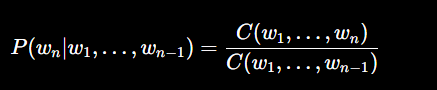

In [37]:
def unsmoothed_probability(
    word,
    context,
    n
):

    # Unigram
    if n == 1:

        return (
            unigram_counts[word]
            / TOTAL_UNIGRAMS
        )


    ngram = context + (word,)

    numerator = (
        ngram_counts[n][ngram]
    )

    denominator = (
        context_counts[n][context]
    )


    if denominator == 0:
        return 0.0


    return (
        numerator / denominator
    )

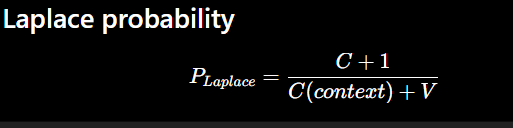

In [38]:
def laplace_probability(
    word,
    context,
    n
):

    # Unigram
    if n == 1:

        return (
            unigram_counts[word] + 1
        ) / (
            TOTAL_UNIGRAMS + V
        )


    ngram = context + (word,)


    return (
        ngram_counts[n][ngram] + 1
    ) / (
        context_counts[n][context] + V
    )

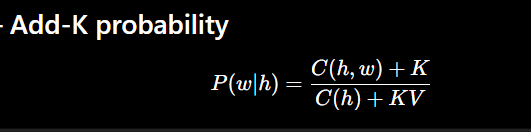

In [39]:
def add_k_probability(
    word,
    context,
    n,
    K
):

    if n == 1:

        return (
            unigram_counts[word] + K
        ) / (
            TOTAL_UNIGRAMS + K * V
        )


    ngram = context + (word,)


    return (
        ngram_counts[n][ngram] + K
    ) / (
        context_counts[n][context]
        + K * V
    )

INTERPOLATED SMOOTHING

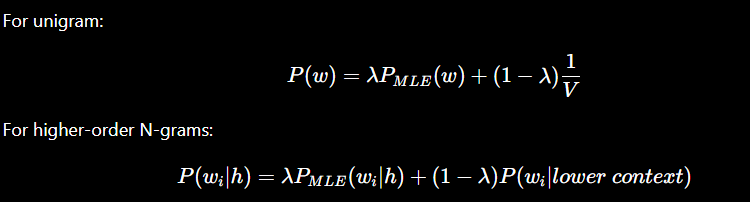

In [40]:
def interpolated_probability(
    word,
    context,
    n,
    lambda_value
):

    # -------------------------
    # UNIGRAM
    # -------------------------

    if n == 1:

        mle_probability = (
            unigram_counts[word]
            / TOTAL_UNIGRAMS
        )

        uniform_probability = (
            1 / V
        )


        return (
            lambda_value
            * mle_probability
            +
            (1 - lambda_value)
            * uniform_probability
        )


    # -------------------------
    # CURRENT ORDER MLE
    # -------------------------

    ngram = context + (word,)

    context_count = (
        context_counts[n][context]
    )


    if context_count > 0:

        mle_probability = (
            ngram_counts[n][ngram]
            / context_count
        )

    else:

        mle_probability = 0.0


    # -------------------------
    # LOWER ORDER
    # -------------------------

    lower_context = context[1:]


    lower_probability = (
        interpolated_probability(
            word,
            lower_context,
            n - 1,
            lambda_value
        )
    )


    return (
        lambda_value
        * mle_probability
        +
        (1 - lambda_value)
        * lower_probability
    )

In [41]:
DISCOUNT = 0.75

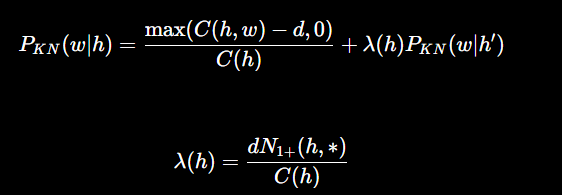

In [42]:
def kneser_ney_probability(
    word,
    context,
    n,
    discount=0.75
):

    # ---------------------------------
    # BASE CASE: UNIGRAM
    # ---------------------------------

    if n == 1:

        continuation_count = (
            unigram_continuation_counts
            .get(word, 0)
        )


        if total_bigram_types == 0:
            return 0.0


        return (
            continuation_count
            / total_bigram_types
        )


    # ---------------------------------
    # CURRENT N-GRAM
    # ---------------------------------

    ngram = context + (word,)

    context_count = (
        context_counts[n][context]
    )


    # Context unseen:
    # back off immediately
    if context_count == 0:

        return kneser_ney_probability(
            word,
            context[1:],
            n - 1,
            discount
        )


    ngram_count = (
        ngram_counts[n][ngram]
    )


    # ---------------------------------
    # DISCOUNTED COUNT
    # ---------------------------------

    first_term = (
        max(
            ngram_count - discount,
            0
        )
        / context_count
    )


    # ---------------------------------
    # NUMBER OF UNIQUE FOLLOWERS
    # ---------------------------------

    unique_followers = (
        unique_follower_counts[n]
        .get(context, 0)
    )


    # ---------------------------------
    # BACKOFF WEIGHT
    # ---------------------------------

    lambda_context = (
        discount
        * unique_followers
        / context_count
    )


    # ---------------------------------
    # LOWER ORDER PROBABILITY
    # ---------------------------------

    lower_probability = (
        kneser_ney_probability(
            word,
            context[1:],
            n - 1,
            discount
        )
    )


    return (
        first_term
        +
        lambda_context
        * lower_probability
    )

In [43]:
def prepare_sentence(
    sentence,
    vocab,
    n
):

    tokens = tokenize(
        sentence
    )

    tokens = map_to_vocabulary(
        tokens,
        vocab
    )


    if n == 1:

        return (
            tokens
            + [END_TOKEN]
        )


    return (
        [START_TOKEN] * (n - 1)
        +
        tokens
        +
        [END_TOKEN]
    )

In [44]:
def sentence_log_probability(
    sentence,
    n,
    smoothing_method,
    K=0.1,
    lambda_value=0.7,
    discount=0.75
):

    sequence = prepare_sentence(
        sentence,
        vocab,
        n
    )


    log_probability = 0.0


    # =================================
    # UNIGRAM
    # =================================

    if n == 1:

        for word in sequence:


            if smoothing_method == "unsmoothed":

                probability = (
                    unsmoothed_probability(
                        word,
                        (),
                        1
                    )
                )


            elif smoothing_method == "laplace":

                probability = (
                    laplace_probability(
                        word,
                        (),
                        1
                    )
                )


            elif smoothing_method == "add_k":

                probability = (
                    add_k_probability(
                        word,
                        (),
                        1,
                        K
                    )
                )


            elif smoothing_method == "interpolated":

                probability = (
                    interpolated_probability(
                        word,
                        (),
                        1,
                        lambda_value
                    )
                )


            elif smoothing_method == "kneser_ney":

                probability = (
                    kneser_ney_probability(
                        word,
                        (),
                        1,
                        discount
                    )
                )


            else:

                raise ValueError(
                    "Unknown smoothing method"
                )


            if probability <= 0:

                return float("-inf")


            log_probability += (
                math.log(probability)
            )


        return log_probability


    # =================================
    # BIGRAM / TRIGRAM / QUADGRAM
    # =================================

    for i in range(
        n - 1,
        len(sequence)
    ):

        word = sequence[i]


        context = tuple(
            sequence[
                i - (n - 1):i
            ]
        )


        if smoothing_method == "unsmoothed":

            probability = (
                unsmoothed_probability(
                    word,
                    context,
                    n
                )
            )


        elif smoothing_method == "laplace":

            probability = (
                laplace_probability(
                    word,
                    context,
                    n
                )
            )


        elif smoothing_method == "add_k":

            probability = (
                add_k_probability(
                    word,
                    context,
                    n,
                    K
                )
            )


        elif smoothing_method == "interpolated":

            probability = (
                interpolated_probability(
                    word,
                    context,
                    n,
                    lambda_value
                )
            )


        elif smoothing_method == "kneser_ney":

            probability = (
                kneser_ney_probability(
                    word,
                    context,
                    n,
                    discount
                )
            )


        else:

            raise ValueError(
                "Unknown smoothing method"
            )


        if probability <= 0:

            return float("-inf")


        log_probability += (
            math.log(probability)
        )


    return log_probability

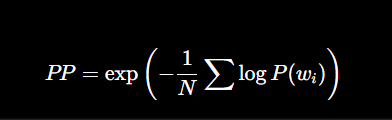

In [45]:
def calculate_perplexity(
    sentences,
    n,
    smoothing_method,
    K=0.1,
    lambda_value=0.7,
    discount=0.75,
    verbose=False
):

    total_log_probability = 0.0

    total_predictions = 0


    for index, sentence in enumerate(sentences):

        tokens = tokenize(
            sentence
        )


        if len(tokens) == 0:
            continue


        log_prob = (
            sentence_log_probability(
                sentence,
                n,
                smoothing_method,
                K,
                lambda_value,
                discount
            )
        )


        # Zero probability means
        # infinite perplexity
        if log_prob == float("-inf"):

            return float("inf")


        total_log_probability += (
            log_prob
        )


        # Number of predicted tokens
        total_predictions += (
            len(tokens) + 1
        )


        if verbose:

            if (
                (index + 1) % 500
                == 0
            ):

                print(
                    f"Processed {index + 1} sentences"
                )


    perplexity = math.exp(
        -total_log_probability
        / total_predictions
    )


    return perplexity

In [46]:
pp = calculate_perplexity(
    test_sentences,
    n=2,
    smoothing_method="laplace",
    verbose=True
)

print(
    "Bigram Laplace Perplexity:",
    pp
)

Processed 500 sentences
Processed 1000 sentences
Bigram Laplace Perplexity: 2750.4179080449862


In [47]:
K_VALUES = [
    0.01,
    0.05,
    0.1,
    0.25,
    0.5,
    0.75
]

In [48]:
def tune_k(
    dev_sentences,
    n,
    k_values
):

    results = []


    for K in k_values:

        pp = calculate_perplexity(
            dev_sentences,
            n=n,
            smoothing_method="add_k",
            K=K
        )


        results.append({
            "K": K,
            "Development Perplexity": pp
        })


        print(
            f"N={n}, "
            f"K={K}, "
            f"PP={pp}"
        )


    results_df = pd.DataFrame(
        results
    )


    results_df = results_df.sort_values(
        by="Development Perplexity"
    )


    best_K = (
        results_df
        .iloc[0]["K"]
    )


    return (
        best_K,
        results_df
    )

In [49]:
best_k_values = {}

k_tuning_results = {}


for n in range(1, 5):

    print("\n")
    print("=" * 60)

    print(
        f"Tuning K for {n}-gram"
    )

    print("=" * 60)


    best_K, tuning_df = tune_k(
        dev_sentences,
        n,
        K_VALUES
    )


    best_k_values[n] = best_K

    k_tuning_results[n] = tuning_df


    print("\nBest K:")
    print(best_K)



Tuning K for 1-gram
N=1, K=0.01, PP=1308.0851307219218
N=1, K=0.05, PP=1308.2770055649805
N=1, K=0.1, PP=1308.5267922741568
N=1, K=0.25, PP=1309.338454064902
N=1, K=0.5, PP=1310.877340463938
N=1, K=0.75, PP=1312.6168132434395

Best K:
0.01


Tuning K for 2-gram
N=2, K=0.01, PP=510.4459994213382
N=2, K=0.05, PP=750.4892186704814
N=2, K=0.1, PP=957.570121095023
N=2, K=0.25, PP=1408.4408510605595
N=2, K=0.5, PP=1965.2296151705693
N=2, K=0.75, PP=2419.914853987242

Best K:
0.01


Tuning K for 3-gram
N=3, K=0.01, PP=4025.3687768271093
N=3, K=0.05, PP=6358.9581565572935
N=3, K=0.1, PP=7989.4623103954245
N=3, K=0.25, PP=10936.130626470138
N=3, K=0.5, PP=13851.1550599566
N=3, K=0.75, PP=15836.48492270117

Best K:
0.01


Tuning K for 4-gram
N=4, K=0.01, PP=16447.558937311886
N=4, K=0.05, PP=20726.473011812872
N=4, K=0.1, PP=23054.206162158353
N=4, K=0.25, PP=26541.43911733249
N=4, K=0.5, PP=29419.11155724784
N=4, K=0.75, PP=31158.76876763887

Best K:
0.01


In [50]:
for n in range(1, 5):

    print(f"\n{n}-GRAM")

    print(
        k_tuning_results[n]
    )


1-GRAM
      K  Development Perplexity
0  0.01             1308.085131
1  0.05             1308.277006
2  0.10             1308.526792
3  0.25             1309.338454
4  0.50             1310.877340
5  0.75             1312.616813

2-GRAM
      K  Development Perplexity
0  0.01              510.445999
1  0.05              750.489219
2  0.10              957.570121
3  0.25             1408.440851
4  0.50             1965.229615
5  0.75             2419.914854

3-GRAM
      K  Development Perplexity
0  0.01             4025.368777
1  0.05             6358.958157
2  0.10             7989.462310
3  0.25            10936.130626
4  0.50            13851.155060
5  0.75            15836.484923

4-GRAM
      K  Development Perplexity
0  0.01            16447.558937
1  0.05            20726.473012
2  0.10            23054.206162
3  0.25            26541.439117
4  0.50            29419.111557
5  0.75            31158.768768


In [51]:
LAMBDA_VALUES = [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9
]

In [52]:
def tune_lambda(
    dev_sentences,
    n,
    lambda_values
):

    results = []


    for lambda_value in lambda_values:


        pp = calculate_perplexity(
            dev_sentences,
            n=n,
            smoothing_method="interpolated",
            lambda_value=lambda_value
        )


        results.append({
            "Lambda": lambda_value,
            "Development Perplexity": pp
        })


        print(
            f"N={n}, "
            f"Lambda={lambda_value}, "
            f"PP={pp}"
        )


    results_df = pd.DataFrame(
        results
    )


    results_df = results_df.sort_values(
        by="Development Perplexity"
    )


    best_lambda = (
        results_df
        .iloc[0]["Lambda"]
    )


    return (
        best_lambda,
        results_df
    )

In [53]:
best_lambda_values = {}

lambda_tuning_results = {}


for n in range(1, 5):

    print("\n")
    print("=" * 60)

    print(
        f"Tuning Lambda for {n}-gram"
    )

    print("=" * 60)


    best_lambda, tuning_df = tune_lambda(
        dev_sentences,
        n,
        LAMBDA_VALUES
    )


    best_lambda_values[n] = best_lambda

    lambda_tuning_results[n] = tuning_df


    print("\nBest Lambda:")
    print(best_lambda)



Tuning Lambda for 1-gram
N=1, Lambda=0.1, PP=5967.3979823044065
N=1, Lambda=0.2, PP=3794.1031635475715
N=1, Lambda=0.3, PP=2871.0989116812657
N=1, Lambda=0.4, PP=2347.232456412168
N=1, Lambda=0.5, PP=2006.9700042746306
N=1, Lambda=0.6, PP=1768.3285389208258
N=1, Lambda=0.7, PP=1593.1808341607637
N=1, Lambda=0.8, PP=1461.9712826969278
N=1, Lambda=0.9, PP=1365.4771211226807

Best Lambda:
0.9


Tuning Lambda for 2-gram
N=2, Lambda=0.1, PP=1053.3676747994264
N=2, Lambda=0.2, PP=629.0353648528854
N=2, Lambda=0.3, PP=470.7757071836576
N=2, Lambda=0.4, PP=389.01215484604364
N=2, Lambda=0.5, PP=341.0974374587687
N=2, Lambda=0.6, PP=312.33314235894227
N=2, Lambda=0.7, PP=297.18140834375373
N=2, Lambda=0.8, PP=295.36612848349495
N=2, Lambda=0.9, PP=316.3104250639043

Best Lambda:
0.8


Tuning Lambda for 3-gram
N=3, Lambda=0.1, PP=666.0499845476432
N=3, Lambda=0.2, PP=427.1323958554841
N=3, Lambda=0.3, PP=348.22760888702146
N=3, Lambda=0.4, PP=317.7717119905794
N=3, Lambda=0.5, PP=313.009274067

In [54]:
parameter_results = []

for n in range(1, 5):

    parameter_results.append({
        "N-gram": n,
        "Best K": best_k_values[n],
        "Best Lambda": best_lambda_values[n]
    })


parameter_df = pd.DataFrame(
    parameter_results
)

parameter_df

,N-gram,Best K,Best Lambda
0,1,0.01,0.9
1,2,0.01,0.8
2,3,0.01,0.5
3,4,0.01,0.3


In [55]:
def build_kn_statistics(
    ngram_counts,
    max_n=4
):

    # Number of unique followers for every context
    unique_followers = {
        n: defaultdict(set)
        for n in range(2, max_n + 1)
    }


    for n in range(2, max_n + 1):

        for ngram in ngram_counts[n]:

            context = ngram[:-1]

            word = ngram[-1]

            unique_followers[n][context].add(
                word
            )


    # Convert sets to counts
    unique_follower_counts = {
        n: {
            context: len(words)
            for context, words
            in unique_followers[n].items()
        }
        for n in range(2, max_n + 1)
    }


    # --------------------------------
    # UNIGRAM CONTINUATION COUNTS
    # --------------------------------

    predecessors = defaultdict(set)


    for bigram in ngram_counts[2]:

        previous_word = bigram[0]

        word = bigram[1]

        predecessors[word].add(
            previous_word
        )


    unigram_continuation_counts = {
        word: len(previous_words)
        for word, previous_words
        in predecessors.items()
    }


    # Total number of distinct bigram types
    total_bigram_types = len(
        ngram_counts[2]
    )


    return (
        unique_follower_counts,
        unigram_continuation_counts,
        total_bigram_types
    )

In [56]:
(
    unique_follower_counts,
    unigram_continuation_counts,
    total_bigram_types
) = build_kn_statistics(
    ngram_counts,
    max_n=4
)

In [57]:
print(
    "Number of contexts:",
    sum(
        len(unique_follower_counts[n])
        for n in range(2, 5)
    )
)

print(
    "Words with continuation counts:",
    len(unigram_continuation_counts)
)

print(
    "Total distinct bigrams:",
    total_bigram_types
)

Number of contexts: 2553400
Words with continuation counts: 52993
Total distinct bigrams: 785989


In [58]:
test_word = list(vocab)[0]

print(
    kneser_ney_probability(
        word=test_word,
        context=(),
        n=1,
        discount=0.75
    )
)

7.633694619135892e-06


In [59]:
methods = [
    "unsmoothed",
    "laplace",
    "add_k",
    "interpolated",
    "kneser_ney"
]


results = []


for n in range(1, 5):

    for method in methods:

        print("\n")
        print("=" * 70)

        print(
            f"Running {n}-gram "
            f"with {method}"
        )

        print("=" * 70)


        # Get tuned parameters
        K = best_k_values[n]

        lambda_value = (
            best_lambda_values[n]
        )


        perplexity = (
            calculate_perplexity(
                test_sentences,
                n=n,
                smoothing_method=method,
                K=K,
                lambda_value=lambda_value,
                discount=0.75,
                verbose=True
            )
        )


        results.append({
            "Language Model":
                f"{n}-gram",

            "N":
                n,

            "Smoothing":
                method,

            "K":
                K if method == "add_k"
                else np.nan,

            "Lambda":
                lambda_value
                if method == "interpolated"
                else np.nan,

            "Discount":
                0.75
                if method == "kneser_ney"
                else np.nan,

            "Test Perplexity":
                perplexity
        })


        print(
            f"\nFinal Perplexity: "
            f"{perplexity}"
        )



Running 1-gram with unsmoothed
Processed 500 sentences
Processed 1000 sentences

Final Perplexity: 1348.2332565664954


Running 1-gram with laplace
Processed 500 sentences
Processed 1000 sentences

Final Perplexity: 1355.0840653327343


Running 1-gram with add_k
Processed 500 sentences
Processed 1000 sentences

Final Perplexity: 1348.284409639604


Running 1-gram with interpolated
Processed 500 sentences
Processed 1000 sentences

Final Perplexity: 1407.2870593833072


Running 1-gram with kneser_ney
Processed 500 sentences
Processed 1000 sentences

Final Perplexity: 1879.4272067131233


Running 2-gram with unsmoothed

Final Perplexity: inf


Running 2-gram with laplace
Processed 500 sentences
Processed 1000 sentences

Final Perplexity: 2750.4179080449862


Running 2-gram with add_k
Processed 500 sentences
Processed 1000 sentences

Final Perplexity: 481.98877396031963


Running 2-gram with interpolated
Processed 500 sentences
Processed 1000 sentences

Final Perplexity: 282.677002629494

In [60]:
results_df = pd.DataFrame(
    results
)

results_df

,Language Model,N,Smoothing,K,Lambda,Discount,Test Perplexity
0,1-gram,1,unsmoothed,NaN,NaN,NaN,1.348233e+03
1,1-gram,1,laplace,NaN,NaN,NaN,1.355084e+03
2,1-gram,1,add_k,0.01,NaN,NaN,1.348284e+03
3,1-gram,1,interpolated,NaN,0.9,NaN,1.407287e+03
4,1-gram,1,kneser_ney,NaN,NaN,0.75,1.879427e+03
5,2-gram,2,unsmoothed,NaN,NaN,NaN,inf
6,2-gram,2,laplace,NaN,NaN,NaN,2.750418e+03
7,2-gram,2,add_k,0.01,NaN,NaN,4.819888e+02
8,2-gram,2,interpolated,NaN,0.8,NaN,2.826770e+02
9,2-gram,2,kneser_ney,NaN,NaN,0.75,2.390210e+02


In [61]:
results_sorted = results_df.sort_values(
    by="Test Perplexity",
    ascending=True
)

results_sorted

,Language Model,N,Smoothing,K,Lambda,Discount,Test Perplexity
14,3-gram,3,kneser_ney,NaN,NaN,0.75,2.049503e+02
19,4-gram,4,kneser_ney,NaN,NaN,0.75,2.156903e+02
9,2-gram,2,kneser_ney,NaN,NaN,0.75,2.390210e+02
8,2-gram,2,interpolated,NaN,0.8,NaN,2.826770e+02
13,3-gram,3,interpolated,NaN,0.5,NaN,2.887617e+02
18,4-gram,4,interpolated,NaN,0.3,NaN,3.781445e+02
7,2-gram,2,add_k,0.01,NaN,NaN,4.819888e+02
0,1-gram,1,unsmoothed,NaN,NaN,NaN,1.348233e+03
2,1-gram,1,add_k,0.01,NaN,NaN,1.348284e+03
1,1-gram,1,laplace,NaN,NaN,NaN,1.355084e+03


In [63]:
# Best smoothing method for each N-gram order
best_per_order = (
    results_df.loc[results_df.groupby("N")["Test Perplexity"].idxmin()]
    [["N", "Language Model", "Smoothing", "Test Perplexity"]]
    .sort_values("N")
    .reset_index(drop=True)
)

print("Best-performing smoothing method at each N-gram order:")
best_per_order.round(2)

Best-performing smoothing method at each N-gram order:


,N,Language Model,Smoothing,Test Perplexity
0,1,1-gram,unsmoothed,1348.23
1,2,2-gram,kneser_ney,239.02
2,3,3-gram,kneser_ney,204.95
3,4,4-gram,kneser_ney,215.69
